In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from mpytools import Catalog
import lsstypes as types


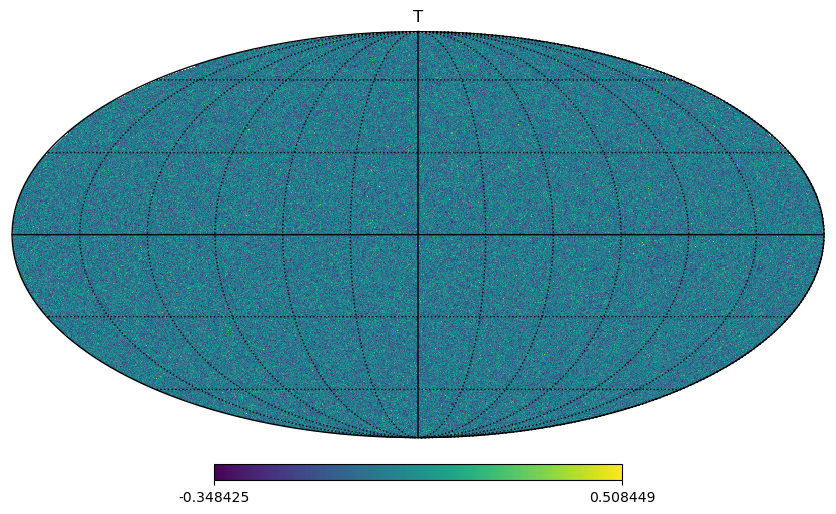

In [2]:
fn = '/dvs_ro/cfs/cdirs/desi/mocks/cai/GLAM-Uchuu/lightcones/lensing/0150/maps/kappa_CMB_Born.fits'
hpmap = hp.read_map(fn)

#tmap = np.asarray(catalog['T'])
hp.mollview(hpmap, nest=False, title='T', flip='astro')
hp.graticule()
plt.show()

### Check the impact of fiber assignment on "angular upweights" = parent / fibered

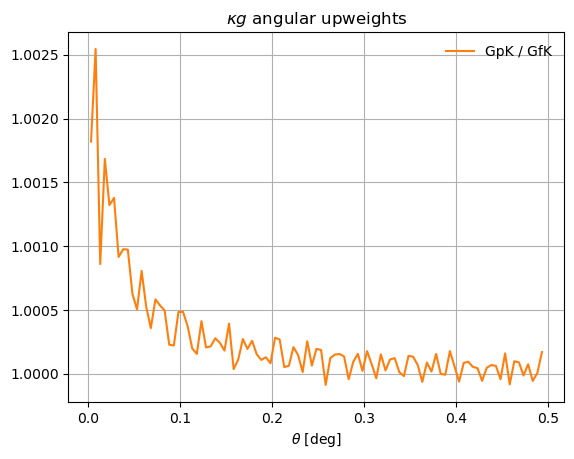

In [3]:
fig, ax = plt.subplots()
imock = 150
fn = f'kappa_fiber_assignment/all_counts_{imock:04d}.h5'
counts = types.read(fn)
theta = counts.get('GG').coords('theta')
# Parent galaxies - Kappa / (Fibered galaxies - Kappa)
ax.plot(theta, counts.get('GpK').value() / counts.get('GfK').value(), color='C1', label=r'GpK / GfK')
#ax.plot(theta, 0.4 * (counts.get('GpK').value() / counts.get('RK1').value() - 1.) + 1., color='C2', label=r'0.4 (GpK / R1 - 1) + 1')s
ax.set_xlabel(r'$\theta$ [$\mathrm{deg}$]')
ax.grid(True)
ax.legend(frameon=False)
#ax.set_ylim(0.99, 1.02)
ax.set_title(rf'$\kappa g$ angular upweights');

### Comparing to a toy model (downsample neighbour (< 0.025 deg) galaxies)
And upweighting the fibered galaxy by the number of missing galaxies

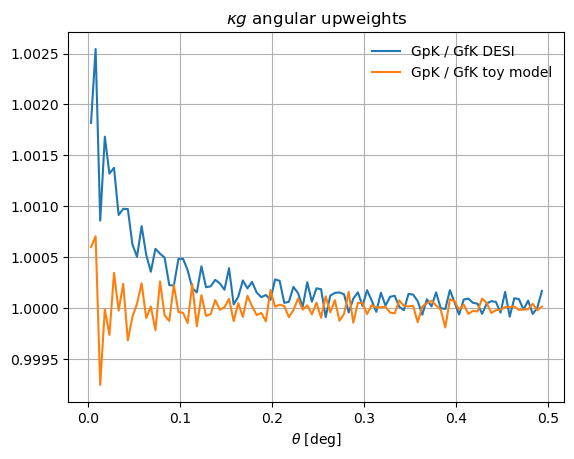

In [4]:
fig, ax = plt.subplots()
imock = 150
fn = f'kappa_fiber_assignment/all_counts_{imock:04d}.h5'
counts = types.read(fn)
theta = counts.get('GG').coords('theta')
ax.plot(theta, counts.get('GpK').value() / counts.get('GfK').value(), color='C0', label=r'GpK / GfK DESI')
fn = f'kappa_fiber_assignment/all_counts_toy_{imock:04d}.h5'
counts_toy = types.read(fn)
theta = counts_toy.get('GpK').coords('theta')
ax.plot(theta, counts_toy.get('GpK').value() / counts_toy.get('GfK').value(), color='C1', label=r'GpK / GfK toy model')
ax.set_xlabel(r'$\theta$ [$\mathrm{deg}$]')
ax.grid(True)
ax.legend(frameon=False)
#ax.set_ylim(0.99, 1.02)
ax.set_title(rf'$\kappa g$ angular upweights');

### Trying to move FRAC_TLOBS_TILES to the fibered data

kappa_fiber_assignment_tlobs/all_counts_0150.h5


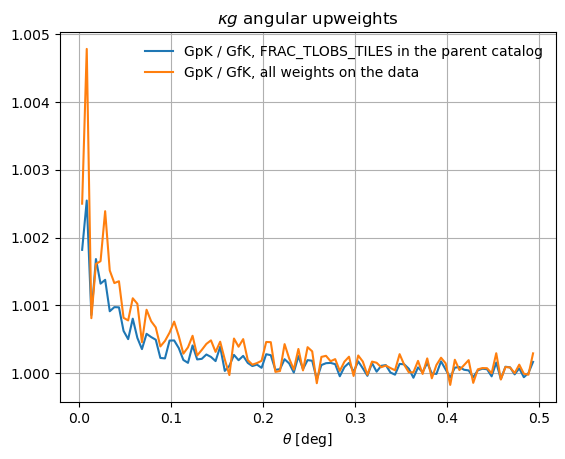

In [12]:
fig, ax = plt.subplots()
imock = 150
fn = f'kappa_fiber_assignment/all_counts_{imock:04d}.h5'
counts = types.read(fn)
theta = counts.get('GG').coords('theta')
ax.plot(theta, counts.get('GpK').value() / counts.get('GfK').value(), color='C0', label=r'GpK / GfK, FRAC_TLOBS_TILES in the parent catalog')
fn = f'kappa_fiber_assignment_tlobs/all_counts_{imock:04d}.h5'
counts_toy = types.read(fn)
theta = counts_toy.get('GpK').coords('theta')
ax.plot(theta, counts_toy.get('GpK').value() / counts_toy.get('GfK').value(), color='C1', label=r'GpK / GfK, all weights on the data')
ax.set_xlabel(r'$\theta$ [$\mathrm{deg}$]')
ax.grid(True)
ax.legend(frameon=False)
#ax.set_ylim(0.99, 1.02)
ax.set_title(rf'$\kappa g$ angular upweights');

### For comparison, galaxy - galaxy angular upweights

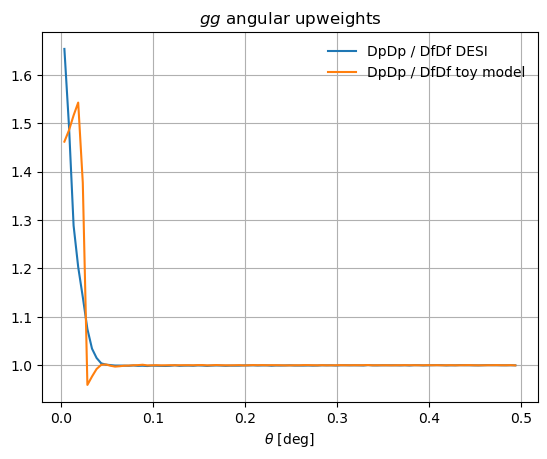

In [6]:
fig, ax = plt.subplots()
imock = 150
fn = f'kappa_fiber_assignment/all_counts_{imock:04d}.h5'
counts = types.read(fn)
theta = counts.get('GG').coords('theta')
ax.plot(theta, counts.get('GpGp').value() / counts.get('GfGf').value(), color='C0', label=r'DpDp / DfDf DESI')
fn = f'kappa_fiber_assignment/all_counts_toy_{imock:04d}.h5'
counts_toy = types.read(fn)
theta = counts_toy.get('GpGp').coords('theta')
ax.plot(theta, counts_toy.get('GpGp').value() / counts_toy.get('GfGf').value(), color='C1', label=r'DpDp / DfDf toy model')
ax.set_xlabel(r'$\theta$ [$\mathrm{deg}$]')
ax.grid(True)
ax.legend(frameon=False)
#ax.set_ylim(0.99, 1.02)
ax.set_title(rf'$g g$ angular upweights');

### Seems to be a slight offset in the fibered vs parent samples
(which we can reduce in the meantime by renormalizing pair counts)

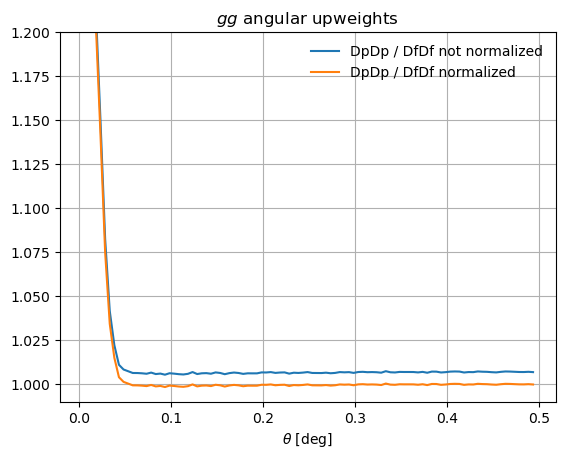

In [7]:
fig, ax = plt.subplots()
imock = 150
#fn = f'/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/fiber_assignment_systematics/glam-uchuu-v2-altmtl/mock{imock:d}/particle2_angular_upweights_ELG_LOPnotqso_z1.1-1.6_NGC_weight-default-FKP.h5'
#angular = types.read(fn).get('DD')
#theta = angular.coords('theta')
#ax.plot(theta, angular.value(), color='C0')


fn = f'kappa_fiber_assignment/all_counts_{imock:04d}.h5'
counts = types.read(fn)
theta = counts.get('GpGp').coords('theta') 
ax.plot(theta, counts.get('GpGp').values('counts') / counts.get('GfGf').values('counts'), color='C0', label=r'DpDp / DfDf not normalized')
ax.plot(theta, counts.get('GpGp').value() / counts.get('GfGf').value(), color='C1', label=r'DpDp / DfDf normalized')

ax.set_xlabel(r'$\theta$ [$\mathrm{deg}$]')
ax.grid(True)
ax.legend(frameon=False)
#ax.set_xlim(0.0, 0.1)
ax.set_ylim(0.99, 1.2)
#ax.set_ylim(0.99, 1.01)
ax.set_title(f'$gg$ angular upweights');

### Cross-correlation, with angular upweighting (based on parent and fibered samples)

Text(0.5, 1.0, '$\\kappa g$ correlation')

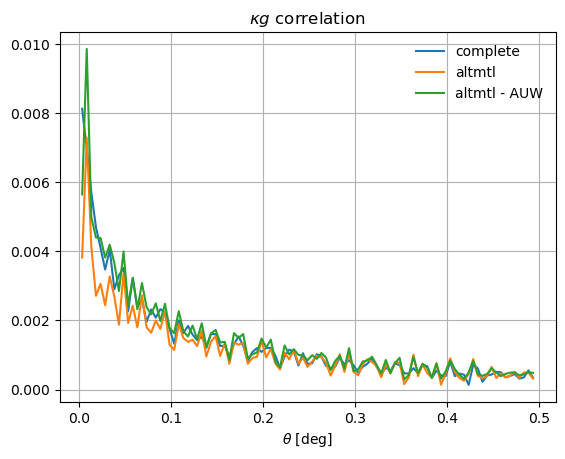

In [8]:
fig, ax = plt.subplots()
imock = 150
fn = f'kappa_fiber_assignment/all_counts_{imock:04d}.h5'
counts = types.read(fn)
theta = counts.get('GK').coords('theta')
correlation_complete = (counts.get('GcK').value() - 2. * counts.get('RcK').value()) / counts.get('RcK1').value() + 1
ax.plot(theta, correlation_complete, color='C0', label=r'complete')
correlation_altmtl = (counts.get('GK').value() - 2. * counts.get('RK').value()) / counts.get('RK1').value() + 1.
ax.plot(theta, correlation_altmtl, color='C1', label=r'altmtl')
auw = counts.get('GpK').value() / counts.get('GfK').value()
correlation_altmtl_auw = (auw * counts.get('GK').value() - 2. * counts.get('RK').value()) / counts.get('RK1').value() + 1.
ax.plot(theta, correlation_altmtl_auw, color='C2', label=r'altmtl - AUW')

ax.set_xlabel(r'$\theta$ [$\mathrm{deg}$]')
ax.grid(True)
ax.legend(frameon=False)
ax.set_title(rf'$\kappa g$ correlation')

### Moving to harmonic space

In [9]:
wtheta = correlation_altmtl_auw - correlation_altmtl

import numpy as np
from scipy.integrate import simpson
from scipy.special import j0

def wtheta_to_cell_flatsky(theta, wtheta, ell):
    """
    Flat-sky approximation:
        w(theta) = ∫ ell d ell / (2pi) C_ell J0(ell theta)

    inverse:
        C_ell = 2pi ∫ theta dtheta w(theta) J0(ell theta)
    """
    theta = np.asarray(theta)
    wtheta = np.asarray(wtheta)
    theta = np.deg2rad(theta)

    order = np.argsort(theta)
    theta = theta[order]
    wtheta = wtheta[order]

    cell = np.empty_like(ell, dtype=float)

    for i, l in enumerate(ell):
        cell[i] = 2 * np.pi * simpson(theta * wtheta * j0(l * theta), x=theta)

    return cell

ell = np.arange(10, 1000)
cell = wtheta_to_cell_flatsky(theta, wtheta, ell)

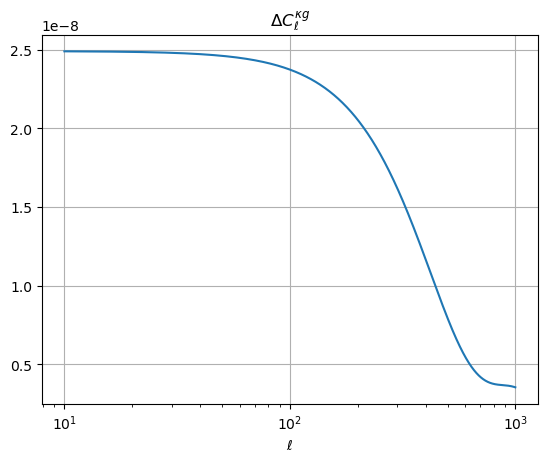

In [10]:
fig, ax = plt.subplots()
ax.plot(ell, cell)
ax.set_xlabel(r'$\ell$')
ax.set_xscale('log')
ax.grid(True)
ax.set_title(r'$\Delta C_\ell^{\kappa g}$');